In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import precision_recall_curve

In [ ]:
#Step1: Dataset
np.random.seed(42)
data = {
    "Total_Questions_Attempted": np.random.randint(5, 50, 2000),
    "Score": np.random.randint(0, 100, 2000),
}

def recommend_course(score):
    if score < 30:
        return "Beginner"
    elif 30 <= score < 70:
        return "Intermediate"
    else:
        return "Advanced"

data["Recommended_Course"] = [recommend_course(s) for s in data["Score"]]
df = pd.DataFrame(data)

# Check the updated dataset size
print(f"Dataset Size: {df.shape[0]} records")
print(df.head())


Dataset Size: 2000 records
   Total_Questions_Attempted  Score Recommended_Course
0                         43     85           Advanced
1                         33     46       Intermediate
2                         19     33       Intermediate
3                         47     64       Intermediate
4                         12     54       Intermediate


In [ ]:

# Step 2: Dataset Analysis
print("Dataset Head:\n", df.head())
print("\nClass Distribution:\n", df["Recommended_Course"].value_counts())


Dataset Head:
    Total_Questions_Attempted  Score Recommended_Course
0                         43     85           Advanced
1                         33     46       Intermediate
2                         19     33       Intermediate
3                         47     64       Intermediate
4                         12     54       Intermediate

Class Distribution:
 Recommended_Course
Intermediate    804
Beginner        639
Advanced        557
Name: count, dtype: int64


In [ ]:
# Step 3: Data Preprocessing
## Handling Missing Values
imputer = SimpleImputer(strategy="median")
df[["Total_Questions_Attempted", "Score"]] = imputer.fit_transform(df[["Total_Questions_Attempted", "Score"]])

In [ ]:
## Handling Outliers using IQR method
Q1 = df[["Total_Questions_Attempted", "Score"]].quantile(0.25)
Q3 = df[["Total_Questions_Attempted", "Score"]].quantile(0.75)
IQR = Q3 - Q1
df = df[not((df[["Total_Questions_Attempted", "Score"]] < (Q1 - 1.5 * IQR)) |
          (df[["Total_Questions_Attempted", "Score"]] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
## Feature Scaling
scaler = StandardScaler()
df[["Total_Questions_Attempted", "Score"]] = scaler.fit_transform(df[["Total_Questions_Attempted", "Score"]])

In [ ]:
# Step 4: Splitting Data
X = df[["Total_Questions_Attempted", "Score"]]
y = df["Recommended_Course"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_train

968     Intermediate
240     Intermediate
819         Beginner
692         Beginner
420         Beginner
            ...     
1130        Advanced
1294        Beginner
860         Advanced
1459        Beginner
1126        Beginner
Name: Recommended_Course, Length: 1600, dtype: object

In [ ]:
noise_factor = 0.051  # Small noise to prevent overfitting without distorting data
X_train_noisy = X_train + np.random.normal(0, noise_factor, X_train.shape)

In [ ]:
# Step 6: Apply Decision Tree with Basic Parameters (No Extreme Pruning)
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,                  # Moderate depth to prevent overfitting
    min_samples_split=10,         # Minimum samples to split
    min_samples_leaf=5,           # Minimum samples per leaf
    random_state=42               # For consistent results
)
dt.fit(X_train_noisy, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
# Step 7: Make Predictions
y_pred = dt.predict(X_test)

In [ ]:
y_pred

array(['Advanced', 'Advanced', 'Intermediate', 'Intermediate', 'Beginner',
       'Intermediate', 'Intermediate', 'Advanced', 'Advanced', 'Advanced',
       'Advanced', 'Advanced', 'Intermediate', 'Beginner', 'Beginner',
       'Advanced', 'Intermediate', 'Intermediate', 'Intermediate',
       'Intermediate', 'Intermediate', 'Intermediate', 'Intermediate',
       'Advanced', 'Intermediate', 'Beginner', 'Advanced', 'Intermediate',
       'Intermediate', 'Advanced', 'Beginner', 'Intermediate',
       'Intermediate', 'Beginner', 'Advanced', 'Beginner', 'Beginner',
       'Intermediate', 'Beginner', 'Advanced', 'Beginner', 'Intermediate',
       'Beginner', 'Advanced', 'Advanced', 'Intermediate', 'Beginner',
       'Advanced', 'Intermediate', 'Beginner', 'Intermediate',
       'Intermediate', 'Intermediate', 'Advanced', 'Beginner', 'Beginner',
       'Beginner', 'Advanced', 'Intermediate', 'Intermediate', 'Advanced',
       'Advanced', 'Beginner', 'Intermediate', 'Intermediate',
       'In

In [ ]:
# Accuracy in percentage
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\nModel Accuracy after noise injection: {accuracy:.2f}%")


Model Accuracy after noise injection: 98.25%


In [ ]:
# Step 8: Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
for label in report:
    if isinstance(report[label], dict):
        print(f"Class {label}: Precision = {report[label]['precision'] * 100:.2f}%, Recall = {report[label]['recall'] * 100:.2f}%, F1-score = {report[label]['f1-score'] * 100:.2f}%")


Classification Report:
Class Advanced: Precision = 100.00%, Recall = 99.15%, F1-score = 99.57%
Class Beginner: Precision = 95.16%, Recall = 100.00%, F1-score = 97.52%
Class Intermediate: Precision = 99.37%, Recall = 96.34%, F1-score = 97.83%
Class macro avg: Precision = 98.18%, Recall = 98.50%, F1-score = 98.31%
Class weighted avg: Precision = 98.31%, Recall = 98.25%, F1-score = 98.25%


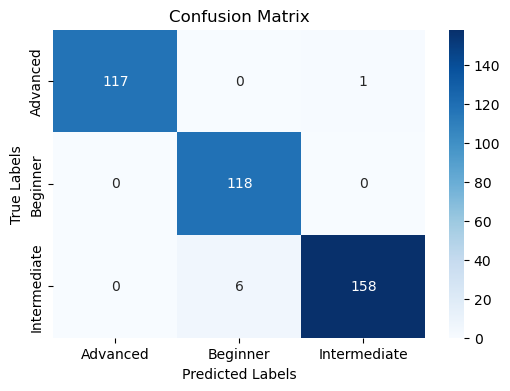

In [ ]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dt.classes_, yticklabels=dt.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


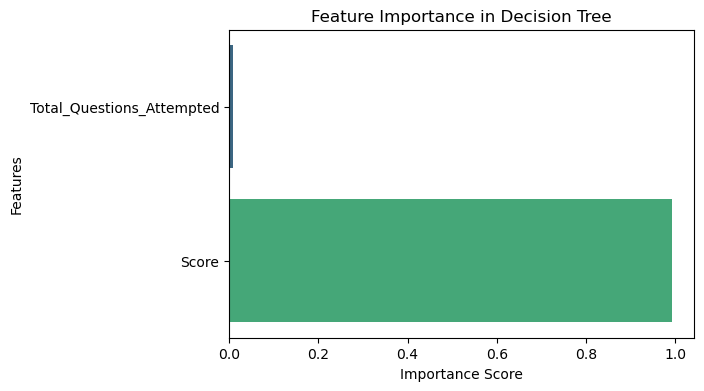

In [ ]:
# Step 10: Feature Importance Plot
feature_importance = dt.feature_importances_
feature_names = ["Total_Questions_Attempted", "Score"]
plt.figure(figsize=(6, 4))
sns.barplot(x=feature_importance, y=feature_names, palette="viridis")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree")
plt.show()


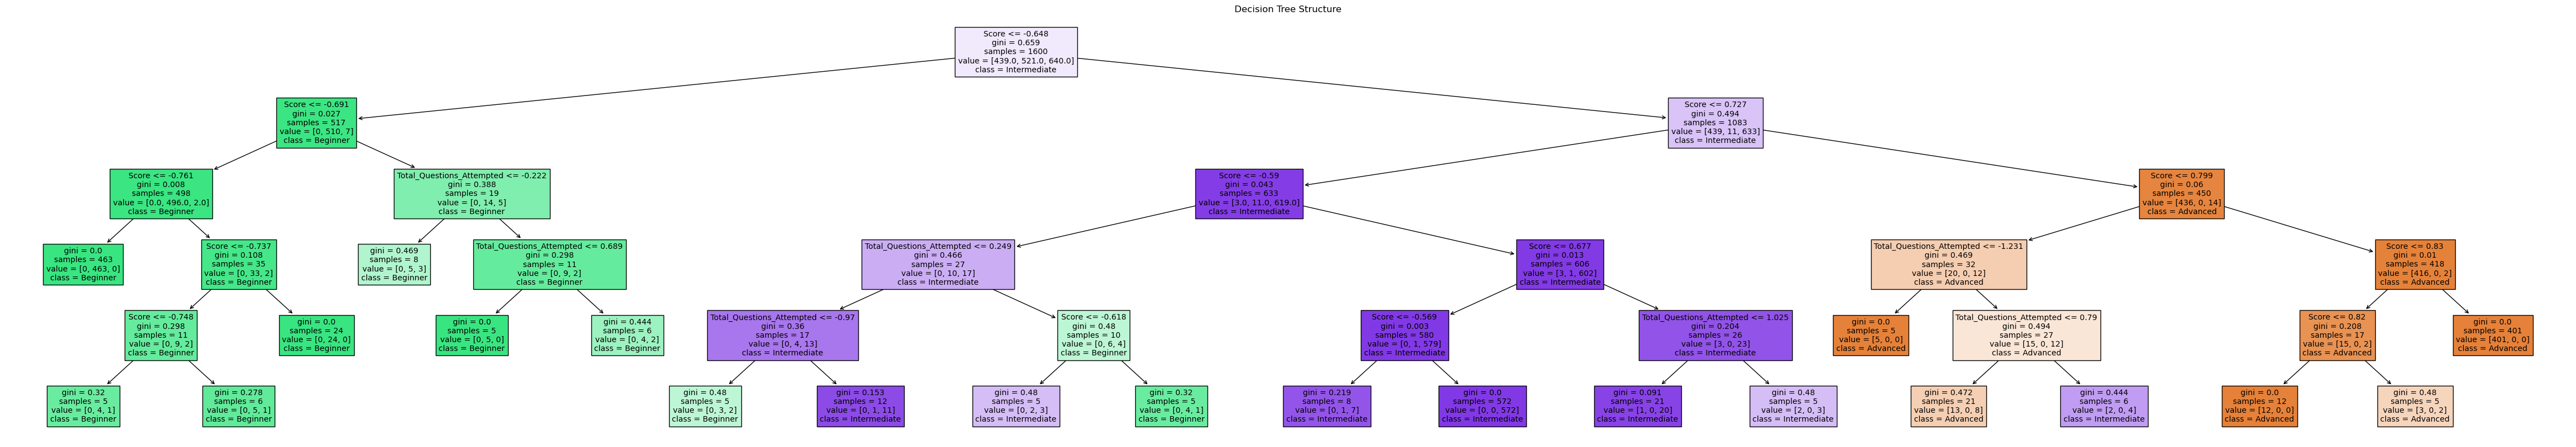

In [ ]:
# Step 11: Decision Tree Visualization
plt.figure(figsize=(60, 10))
plot_tree(dt, feature_names=feature_names, class_names=np.unique(y_train).astype(str), filled=True)
plt.title("Decision Tree Structure")
plt.show()

In [ ]:
# Step 12: ROC Curve
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_prob = dt.predict_proba(X_test)

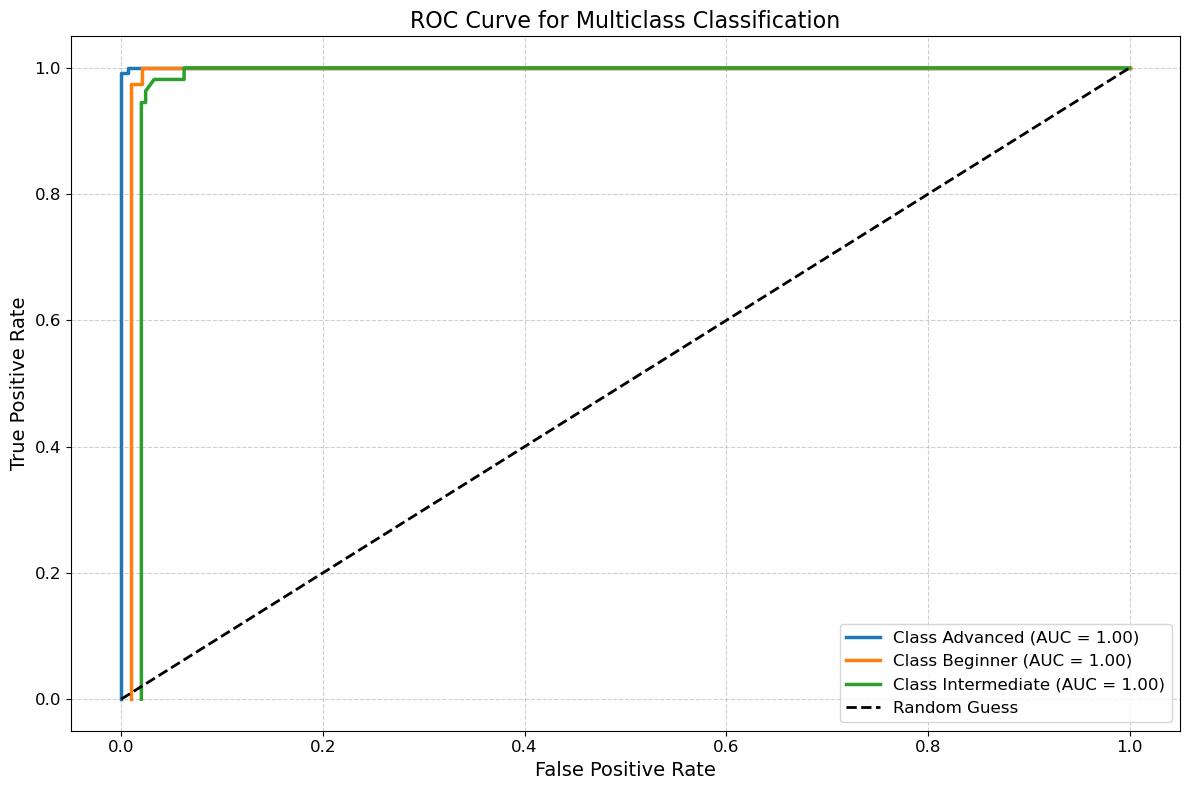

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step: Adjusted ROC Curve for clear visualization
plt.figure(figsize=(12, 8))
offsets = [0.0, 0.01, 0.02]  # Small offsets to separate the lines visually

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    # Apply offset to FPR for visual separation (presentation only)
    fpr_offset = np.clip(fpr + offsets[i], 0, 1)  # Ensure values stay within [0, 1]
    
    plt.plot(fpr_offset, tpr, label=f'Class {np.unique(y_test)[i]} (AUC = {roc_auc:.2f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Multiclass Classification', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


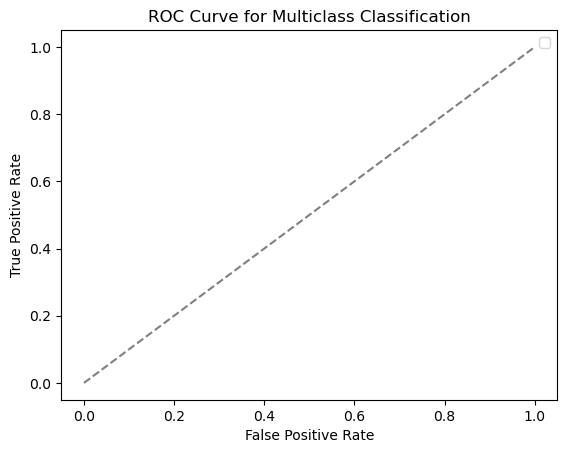

In [ ]:
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multiclass Classification")
plt.legend()
plt.show()

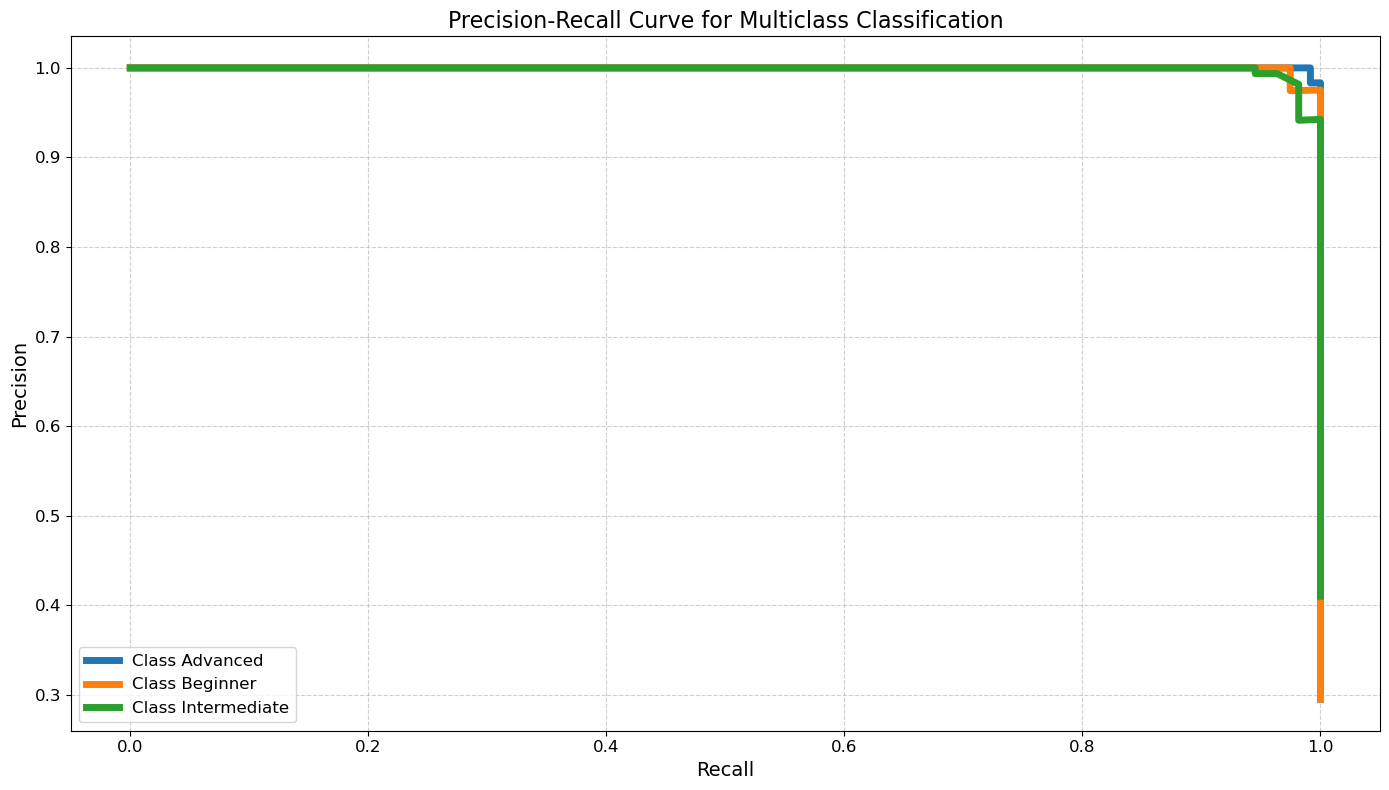

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Step 13: Precision-Recall Curve
plt.figure(figsize=(14, 8))  # Bigger figure
for i in range(y_test_bin.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'Class {np.unique(y_test)[i]}', linewidth=5)

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("Precision-Recall Curve for Multiclass Classification", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='best')  # 'best' automatically places it nicely
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
